# AA/OAA -数学原理及实现
----

## 数学原理

### 1. Grover 算法和 Amplitude Amplification 的关系
Grover 算法中初始态固定为
$$
H^{\otimes n}\left|0^n\right\rangle
$$
而 AA 中允许任意的状态制备算子 $U_0$. 设初态
$$
U_0\left|0\right\rangle=\left|\psi\right\rangle=\sin\theta\left|\psi_{G}\right\rangle+\cos\theta\left|\psi_{B}\right\rangle
$$
初始成功概率为
$$
p=\sin^2\theta
$$
所以
$$
\theta=\arcsin\sqrt{p}
$$
因此，Grover 搜索算法可以看做是 AA 的一种特殊情况.

### 2. 两个反射
AA 的核心仍然是两个反射.第一个是关于 good space 的反射 $R_{good}$, 其作用为
$$
R_{good}\left|\psi_{G}\right\rangle = -\left|\psi_{G}\right\rangle,\qquad R_{good}\left|\psi_{B}\right\rangle = \left|\psi_{B}\right\rangle
$$
在二维基底 $\{ \left|\psi_{G}\right\rangle, \left|\psi_{B}\right\rangle \}$ 下(不变子空间)，其矩阵形式为
$$
R_{good} = \begin{bmatrix}
-1 & 0 \\ 0 & 1
\end{bmatrix}
$$
第二个是关于初始态的反射
$$
R_0=2\left|\psi\right\rangle \left\langle\psi\right|-I
$$
于是 AA operator 为
$$
Q=R_0R_{good}
$$

### 3. 振幅放大
对于初态
$$
\left| \psi \right\rangle = \sin\left|\psi_{G}\right\rangle+\cos\left|\psi_{B}\right\rangle
$$
执行 k 次 AA 操作后
$$
Q^k\left| \psi \right\rangle = \sin[(2k+1)\theta]\left|\psi_{G}\right\rangle+\cos[(2k+1)\theta]\left|\psi_{B}\right\rangle
$$
因此成功概率为
$$
P_k = \sin^2[(2k+1)\theta]
$$

## 代码实现

In [1]:
# 导入 unitarylab 并测试
import unitarylab

print(unitarylab.__version__)

1.1.5


[AA]: Starting Amplitude Amplification Algorithm
[AA]: Input parameters: 
        - U = Given quantum circuit
        - Target State = [0, 1]
        - Initial Success Probability = 0.1
        - Repetitions = None
[AA]: Stage 1: Parameter preparation
[AA]:   Data register size: 2 (total 3 qubits)
[AA]:   Target state condition: Qubits [0, 1] must all be |0>
[AA]:   Initial success probability p: 0.1000
[AA]:   Initial angle theta/2: 0.3218 radians
[AA]:   Iteration count: 2
[AA]: Stage 2: Building quantum circuit
[AA]: Stage 3: Executing quantum simulation
[AA]:   Computation time: 0.0075 seconds
[AA]:   Number of valid measured basis states: 2
[AA]: Stage 4: Classical post-processing (verifying amplification effect)
[AA]:   Initial target state probability: 0.1000
[AA]:   Amplified angle 5 times theta/2: 1.6088 radians
[AA]:   Amplified target state probability: 0.9986
[AA]:   Result verification: success
[AA]: Stage 5: Exporting circuit diagram
[AA]: Output information: 
        - A

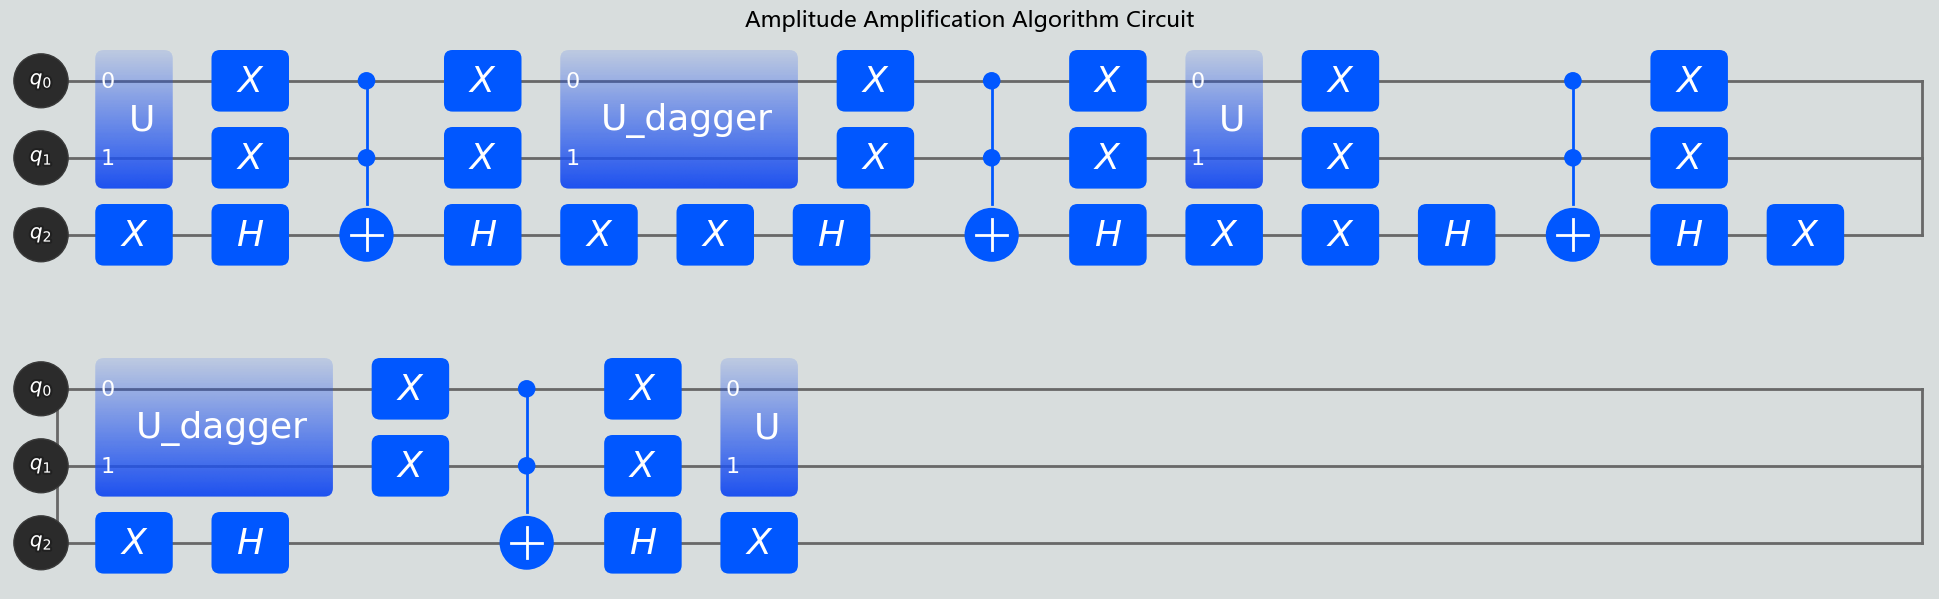

In [ ]:
# 绘制线路图
import math

import numpy as np
from unitarylab.core import Circuit
from unitarylab_algorithms import AmplitudeAmplificationAlgorithm

p0 = 0.1  # 设置初始概率
theta_u = math.acos(math.sqrt(p0))

U = Circuit(2, name="U")
U.ry(2 * theta_u, 0)  # 线路

good_zero_qubits = [0, 1]

%matplotlib inline
aa = AmplitudeAmplificationAlgorithm(text_mode="plain")
aa_result = aa.run(
    U=U,
    good_zero_qubits=good_zero_qubits,
    p=p0,
    reps=None,
    backend="numpy",
    device="cpu",
    dtype=np.complex128,
)


In [3]:
# 手写 AA 数值模拟
import math

import numpy as np

p0 = 0.1  # 初始概率

# 定义初始态
theta = math.asin(math.sqrt(p0))
psi = np.array([math.sqrt(p0), math.sqrt(1 - p0)], dtype=complex)

# Good 反射
R_good = np.array([[-1, 0], [0, 1]], dtype=complex)

# 关于初态反射
R_0 = 2 * np.outer(psi, psi.conj()) - np.eye(2, dtype=complex)

# AA 算子
Q = R_0 @ R_good

# 迭代
k = round(math.pi / (4 * theta) - 0.5)

state = psi.copy()
manual_history = [abs(state[0]) ** 2]

for _ in range(k):
    state = Q @ state

    manual_history.append(abs(state[0]) ** 2)

for iteration, prob in enumerate(manual_history):
    print(f"Iteration {iteration}: {prob:.6f}")

# 解析公式
theory_history = [math.sin((2 * j + 1) * theta) ** 2 for j in range(k + 1)]

for j in range(k + 1):
    print(f"k={j}: manual={manual_history[j]:.10f}, theory={theory_history[j]:.10f}")

Iteration 0: 0.100000
Iteration 1: 0.676000
Iteration 2: 0.998560
k=0: manual=0.1000000000, theory=0.1000000000
k=1: manual=0.6760000000, theory=0.6760000000
k=2: manual=0.9985600000, theory=0.9985600000


In [4]:
official_probability = aa_result["Amplified Target Probability"]
official_reps = aa_result["Repetitions"]

print("Official repetitions =", official_reps)
print("Official P_good =", official_probability)

Official repetitions = 2
Official P_good = 0.9985599999999999


In [5]:
manual_probability = manual_history[-1]

print("\n========== AA Comparison ==========")
print("Theory   =", theory_history[-1])
print("Manual   =", manual_probability)
print("Official =", official_probability)
print("Absolute error =", abs(manual_probability - official_probability))


========== AA Comparison ==========
Theory   = 0.9985600000000001
Manual   = 0.9985599999999999
Official = 0.9985599999999999
Absolute error = 0.0


In [6]:
assert np.isclose(manual_probability, theory_history[-1], atol=1e-10)
assert np.isclose(manual_probability, official_probability, atol=1e-10)

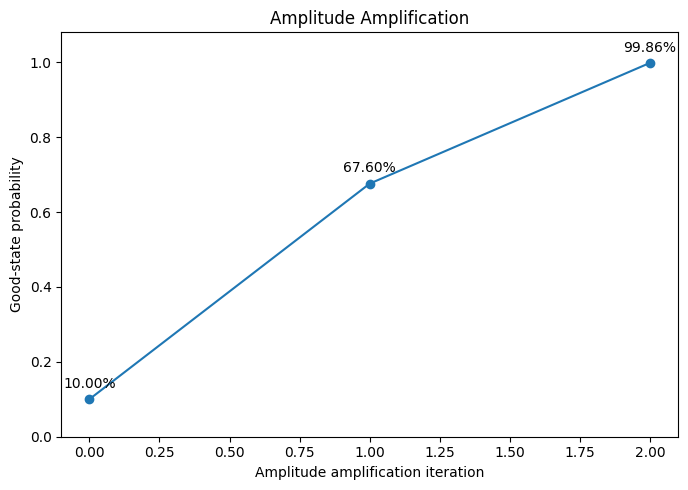

In [7]:
# 画 AA 概率放大图
%matplotlib inline
import matplotlib.pyplot as plt

iterations = list(range(len(manual_history)))

fig, ax = plt.subplots(figsize=(7, 5))
line = ax.plot(iterations, manual_history, marker="o")

for x, y in zip(iterations, manual_history):
    ax.text(x, y + 0.03, f"{y * 100:.2f}%", ha="center")

ax.set_xlabel("Amplitude amplification iteration")
ax.set_ylabel("Good-state probability")
ax.set_title("Amplitude Amplification")
ax.set_ylim(0, 1.08)
fig.tight_layout()

plt.show()

## 数学原理

### 1. 普通 AA 为什么不够 obliviousios ?
对于普通的 AA：
$$
U_0\left|0\right\rangle=\sin\theta\left|\psi_G\right\rangle+\cos\theta\left|\psi_B\right\rangle
$$
初始态已知, 但一般初始态
$$
\left|\psi\right\rangle
$$
未知. 这就是 OAA 的出发点.

### 2. OAA 的输入结构
假设一个较大的 unitary 算子 W 满足
$$
W\left|0^a\right\rangle\left|\psi\right\rangle=\sin\theta\left|0^a\right\rangle\left|\psi_{good}\right\rangle+\cos\theta\left|\Psi^\perp_\psi\right\rangle
$$
并且满足
$$
(\left\langle 0^a\right|\otimes I)\left|\Psi^\perp_\psi\right\rangle=0
$$
所以测量 ancilla $0^a$ 时, 可以得到成功概率为 $p$.


### 3. OAA 的关键 project
定义
$$
P=\left|0^a\right\rangle \left\langle 0^a\right|\otimes I
$$
这里的 $I$ 是作用在 system register 上.因此这个算子只关心 ancilla 是否为 $0^a$.

### 4. 反射算子
定义
$$
R=I-2P
$$
或者不同情况下
$$
R=2P-I
$$
两者只有符号差异. 若采用第一种, 一个常见的 OAA 算子是
$$
Q_{OAA}=-WRW^\dagger R
$$
符号和惩罚顺序在不同论文中会略有不同, 但本质都是一样.

### 5. OAA 后的结果
若 $\sqrt{p}=\sin\theta$, 则
$$
W\left|0^a\right\rangle \left|\psi\right\rangle = \sin\theta\left|good_\psi\right\rangle + \cos\theta\left|bad_\psi\right\rangle
$$
经过 k 次 OAA 后的结果
$$
Q_{OAA}^k W\left|0^a\right\rangle \left|\psi\right\rangle=\sin[(2k+1)\theta]\left|good_\psi\right\rangle + \cos[(2k+1)\theta]\left|bad_\psi\right\rangle
$$
所以成功概率为
$$
p_k=\sin^2[(2k+1)\theta]
$$

### 6. 数值实现
取初始概率 $p=0.1$, ancilla 和 system 都各自有 1 个 qubit.定义
$$
W=B\otimes X
$$
其中
$$
B=\begin{bmatrix}
\sqrt{p} & \sqrt{1-p}\\
\sqrt{1-p} & -\sqrt{p}
\end{bmatrix},\quad X=\begin{bmatrix}
0 & 1\\
1 & 0
\end{bmatrix}
$$
则
$$
W\left|0\right\rangle \left|\psi\right\rangle=\sqrt{p}\left|0\right\rangle X \left|\psi\right\rangle+\sqrt{1-p}\left|1\right\rangle X \left|\psi\right\rangle
$$
测量后得到
$$
\left|0\right\rangle X \left|\psi\right\rangle\
$$
其概率为 $p$.

## 代码实现

In [8]:
# 数值实现
import math

import matplotlib.pyplot as plt
import numpy as np

p0 = 0.1  # 初始概率

B = np.array(
    [[math.sqrt(p0), math.sqrt(1 - p0)], [math.sqrt(1 - p0), -math.sqrt(p0)]],
    dtype=complex,
)
X = np.array([[0, 1], [1, 0]], dtype=complex)
W = np.kron(B, X).astype(complex)

P = np.diag([1, 1, 0, 0]).astype(complex)
R = np.eye(4, dtype=complex) - 2 * P

Q_oaa = -W @ R @ W.conj().T @ R

phi_1 = np.array([1, 0], dtype=complex)
phi_2 = np.array([1, 1], dtype=complex) / math.sqrt(2)


def success_probability(state, projector):

    return float(np.real(state.conj() @ projector @ state))


def run_oaa(phi, reps):
    ancilla_zero = np.array([1, 0], dtype=complex)
    input_state = np.kron(ancilla_zero, phi)

    state = W @ input_state
    history = [success_probability(state, P)]
    for _ in range(reps):
        state = Q_oaa @ state

        history.append(success_probability(state, P))

    return state, history


theta = math.asin(math.sqrt(p0))

k = round(math.pi / (4 * theta) - 0.5)

state_1, history_1 = run_oaa(phi_1, k)
state_2, history_2 = run_oaa(phi_2, k)

print("Input |0>:", history_1)
print("Input |+>:", history_2)


Input |0>: [0.1, 0.6759999999999998, 0.9985599999999999]
Input |+>: [0.09999999999999999, 0.6759999999999998, 0.9985599999999994]


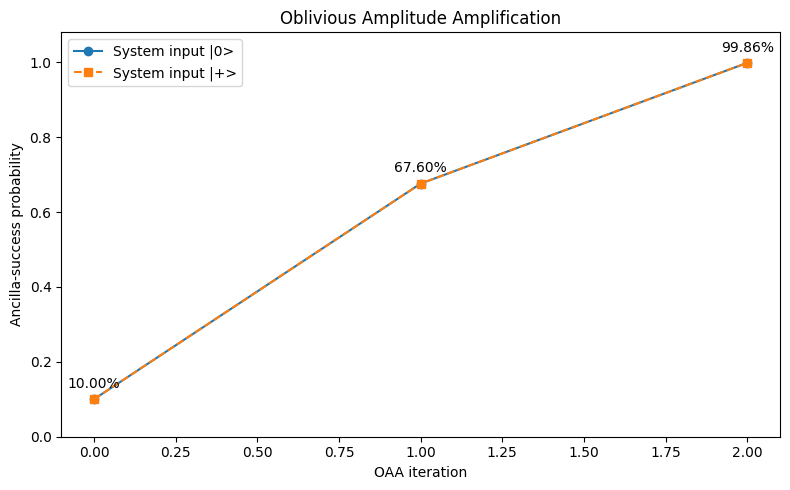

In [9]:
# 绘制概率图
iterations = list(range(len(history_1)))

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(iterations, history_1, marker="o", label="System input |0>")
ax.plot(iterations, history_2, marker="s", linestyle="--", label="System input |+>")

for x, y in zip(iterations, history_1):
    ax.text(x, y + 0.03, f"{y * 100:.2f}%", ha="center")

ax.set_xlabel("OAA iteration")
ax.set_ylabel("Ancilla-success probability")
ax.set_title("Oblivious Amplitude Amplification")
ax.set_ylim(0, 1.08)
ax.legend()
fig.tight_layout()

plt.show()